In [14]:
import pandas as pd

from utils import plot_utils

FilePath = r"C:\imageripping\m4d3\20260125_timeseries_m4_d3_930_las300p900_29.3fps_1x_int220_tonepuff_rest3-241\20260125_timeseries_m4_d3_930_las300p900_29.3fps_1x_int220_tonepuff_rest3-241_Cycle00001_VoltageRecording_001.csv"
df = pd.read_csv(FilePath)

In [15]:
from utils.plot_utils import PlotUtils
from utils.data_utils import DataUtils
from utils.file_utils import FileUtils
from utils.analysis_util import AnalysisUtil
from utils.path_utils import PathUtils

In [16]:
neuro_data = DataUtils.filter_rows_by_threshold(df, 1, 5, ">=")
neuro_data

,Time(ms),Frame begin,behaviorcamframes,optostim,pmtshutterclosing,tone,puff
4,1.334000e-01,5.085449,1.059570,-0.033264,0.004578,0.539246,0.005493
1029,3.431716e+01,5.086975,1.029663,-0.033569,0.005188,0.540161,0.005493
1030,3.435051e+01,5.079956,1.037292,-0.036621,0.005035,0.541382,0.005493
2055,6.853427e+01,5.083923,1.024780,-0.035095,0.004272,0.541077,0.003967
2056,6.856762e+01,5.086975,1.037292,-0.036316,0.004578,0.540466,0.000916
...,...,...,...,...,...,...,...
65491179,2.184131e+06,5.081177,0.257263,-0.032349,0.004730,0.524292,0.003052
65491180,2.184131e+06,5.085449,0.268860,-0.033569,0.005188,0.523987,0.004272
65492202,2.184165e+06,5.078735,0.255432,-0.033875,0.005341,0.524902,0.003662
65492203,2.184166e+06,5.079346,0.268860,-0.032959,0.004425,0.526123,0.000916


In [17]:
neuro_data = DataUtils.keep_first_consecutive_row(neuro_data)
neuro_data

,Time(ms),Frame begin,behaviorcamframes,optostim,pmtshutterclosing,tone,puff
4,1.334000e-01,5.085449,1.059570,-0.033264,0.004578,0.539246,0.005493
1029,3.431716e+01,5.086975,1.029663,-0.033569,0.005188,0.540161,0.005493
2055,6.853427e+01,5.083923,1.024780,-0.035095,0.004272,0.541077,0.003967
3077,1.026180e+02,5.086670,1.025085,-0.031738,0.003510,0.538940,0.000305
4099,1.367017e+02,5.085144,1.023560,-0.030518,0.004578,0.538635,0.004578
...,...,...,...,...,...,...,...
65489134,2.184063e+06,5.072632,0.255127,-0.032043,0.005188,0.523682,0.002136
65490156,2.184097e+06,5.086670,0.258179,-0.034180,0.005341,0.524597,0.000916
65491179,2.184131e+06,5.081177,0.257263,-0.032349,0.004730,0.524292,0.003052
65492202,2.184165e+06,5.078735,0.255432,-0.033875,0.005341,0.524902,0.003662


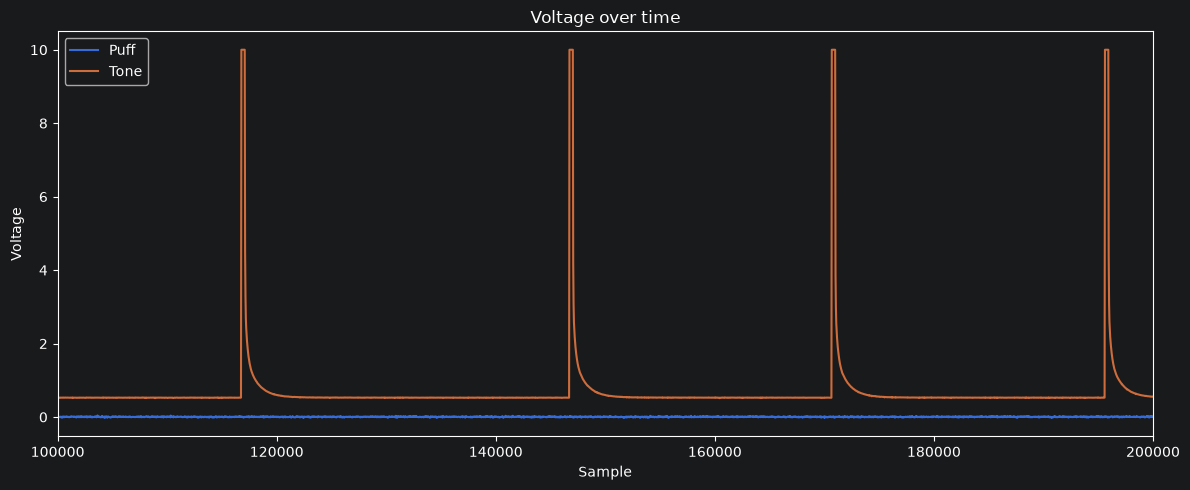

In [13]:
PlotUtils.draw_line_plot(
    y_values=[
        neuro_data.iloc[:, -1],
        neuro_data.iloc[:, -2]
    ],
    x_values=neuro_data.iloc[:, 0],
    y_label="Voltage",
    labels=["Puff", "Tone"],
    title="Voltage over time",
    x_start=100000,
    x_stop=200000
)

In [16]:
from utils.analysis_util import AnalysisUtil
peaks, time = AnalysisUtil.find_event(neuro_data, 6, 0, prominence = 0.5, values = True)

In [17]:
len(time)

57

In [ ]:
PlotUtils.draw_histogram(neuro_data.iloc[:,1], bins = 10)

In [ ]:
neuro_data.iloc[:,1]

In [9]:
F_path = r"C:\imageripping\m6d1\20260124_timeseries_m6_d1_900_las500p900_29.3fps_1x_int187_tonepuff-223\suite2p\plane0\Fall.mat"
suite2p_data = FileUtils.read_mat_file(F_path)

In [10]:
print(suite2p_data.keys())
F = suite2p_data['F']

dict_keys(['__header__', '__version__', '__globals__', 'stat', 'ops', 'F', 'Fneu', 'spks', 'iscell', 'redcell'])


In [11]:
F

array([[ 64.63144 ,  81.73183 ,  90.35979 , ...,  41.736073,  43.210186,
         65.146126],
       [376.46188 , 162.93333 , 329.72488 , ..., 367.35864 , 194.84698 ,
        212.88092 ],
       [ 42.17794 , 214.37474 , 189.63924 , ..., 161.13737 , 206.71112 ,
         53.64132 ],
       ...,
       [105.88441 , 140.51135 , 207.06209 , ..., 157.63072 , 160.36043 ,
        151.72458 ],
       [129.9508  , 107.92084 , 103.64945 , ..., 103.18943 , 198.60341 ,
         95.428764],
       [ 99.13013 , 291.45483 ,  32.279346, ..., 185.05928 ,  42.670258,
         79.70181 ]], shape=(316, 140725), dtype=float32)

In [ ]:
from utils.path_utils import PathUtils
mouse_id = PathUtils.extract_mouse_id(FilePath)
mouse_dir = PathUtils.make_mouse_plot_dir(mouse_id)
PlotUtils.draw_line_plot(
        neuro_data.iloc[:, -1],
        y_label=neuro_data.columns[-1],
        title="Voltage over time",
        save_path = PathUtils.join_path(mouse_dir, f"{mouse_id}_{neuro_data.columns[-1]}.png")
    )

In [ ]:
tone_peaks, tone_peaks_time = AnalysisUtil.find_event(neuro, " tone",
                                                          "Time(ms)", values = True)

In [ ]:
neuro_data

In [ ]:
filtered_voltage_data = DataUtils.reset_row_numbers(neuro_data, drop = True)

tone_peaks, tone_peaks_time = AnalysisUtil.find_event(filtered_voltage_data, " tone",
                                                          "Time(ms)", values = True)

tone_peaks_time = DataUtils.reset_row_numbers(tone_peaks_time, drop = False)

tone_peaks_time

In [ ]:
mouse_id = PathUtils.extract_mouse_id(FilePath)
mouse_dir = PathUtils.make_mouse_file_dir(mouse_id)
path = PathUtils.join_path(mouse_dir, f"{mouse_id}_{filtered_voltage_data.columns[-1]}.csv")
FileUtils.write_csv_file(path, tone_peaks_time)

In [ ]:
path